# CIC3: Community Structure Sweep (degree-corrected)

Investigates how community structure affects seeding strategy performance
under the CIC3 metric, **while holding average degree approximately fixed**.

## Why a 1D constant-budget sweep

The original 2D sweep (`p_intra` x `p_inter` independent) confounded community
structure with average degree: as `p_inter` rose, total edges rose, and
strategies that benefit from higher density got an unfair lift unrelated
to community structure per se.

We now sweep along a 1D curve where the expected total edge count is
approximately constant. Two effects need balancing:

1. **Direct edge sampling.** Variable-part pair-slots:
   - `A = 52 * C(9, 2) = 1872` intra-regular pair-slots
   - `B = C(52, 2) * 9^2 = 107406` inter-regular pair-slots

2. **Triangle fill (RSC convention).** Triangles add any missing constituent
   edges. Each intra-regular pair has `n - 2 = 7` candidate "third nodes"
   that could form a triangle covering it, each with probability
   `p_tri = 0.2`. So a missing intra pair gets filled by some triangle with
   probability `f_tri = 1 - (1 - 0.2)^7 ~ 0.7903` regardless of `p_intra`.

   The expected fraction of intra-regular pair-slots that end up as edges is
   `f(p_intra) = p_intra + (1 - p_intra) * f_tri = f_tri + (1 - f_tri) * p_intra`.

Putting both together, the constant-budget equation
`A * f(p_intra) + B * p_inter = A` gives:

```
p_intra = 1 - (B/A) / (1 - f_tri) * p_inter   with slope ~ 273.6
```

So `p_inter` sweeps from 0 (well-separated full cliques) up to ~0.0035
(`p_intra ~ 0.04`, communities barely distinguishable from background).
The absolute `p_inter` numbers look small because intra-community triangles
already account for most intra edges - reducing `p_intra` frees up little
edge budget for `p_inter` to consume. Hub-community parameters and triangle
probabilities are held fixed, so any residual `k_avg` drift is second-order
(triangle/edge sampling overlap, not modeled exactly).

## Output

1. Line plot: mean `A_g^td` vs `p_inter` for each strategy (top axis annotated
   with the corresponding `p_intra`).
2. Difference plot: each strategy minus Random baseline.
3. Sanity-check plot: realized `k_avg` and `k_delta_avg` across the sweep.
4. Summary table: best strategy at each sweep point.


In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import math

from scm import SBMGenerator, CIC3Simulator
from scm import (
    MultiRandomSeeding, MultiHighDegreeSeeding, MultiHighSimplexSeeding,
    CommunityLouvainSeeding, CommunityFarthestFirstSeeding,
)
from scm.analysis import (
    attainment, time_discounted_attainment,
    exponential_decay, no_decay,
)

STRATEGIES = [
    ("Random", MultiRandomSeeding),
    ("High Degree", MultiHighDegreeSeeding),
    # ("High 2-Simplex", MultiHighSimplexSeeding),
    # ("Louvain", CommunityLouvainSeeding),
    ("Farthest-First", CommunityFarthestFirstSeeding),
]

## Shared parameters

In [3]:
# --- Network ---
N = 500
TOPO_SEED = 2025

# Community structure: 52 small (size 9) + 1 hub (size 32)
REGULAR_K = 52
REGULAR_SIZE = 9
HUB_SIZE = 32
COMMUNITY_SIZES = [REGULAR_SIZE] * REGULAR_K + [HUB_SIZE]
assert sum(COMMUNITY_SIZES) == N
TOTAL_K = len(COMMUNITY_SIZES)  # 53

# Hub is fixed throughout the sweep
HUB_INTRA_P = 0.5
HUB_EDGE_P = 0.15
HUB_TRI_P = 0.04

# Triangle probability for regular communities (fixed)
REGULAR_TRI_P = 0.2

# --- Constant-edge-budget curve (with triangle-fill correction) ---
# Direct-sampling pair-slots:
#   A = 52 * C(9, 2) = 1872          (intra-regular)
#   B = C(52, 2) * 9^2 = 107406      (inter-regular)
# Triangle fill probability for an intra-regular pair (RSC convention):
#   f_tri = 1 - (1 - p_tri)^(n - 2)
# Effective intra-regular edge fraction:
#   f(p_intra) = p_intra + (1 - p_intra) * f_tri
# Constant-budget eqn  A * f(p_intra) + B * p_inter = A  yields
#   p_intra = 1 - (B/A) / (1 - f_tri) * p_inter
A_PAIRS = REGULAR_K * math.comb(REGULAR_SIZE, 2)        # 1872
B_PAIRS = math.comb(REGULAR_K, 2) * REGULAR_SIZE ** 2   # 107406
F_TRI = 1.0 - (1.0 - REGULAR_TRI_P) ** (REGULAR_SIZE - 2)
SLOPE = (B_PAIRS / A_PAIRS) / (1.0 - F_TRI)             # ~273.6


def p_intra_for(p_inter):
    """Return p_intra that keeps the variable-part edge budget constant,
    accounting for triangle fill of missing intra-regular edges."""
    return 1.0 - SLOPE * p_inter


# --- Contagion ---
C = 50
BETA = 0.04
BETA_DELTA = 0.03
BETAS = [BETA] * C
BETA_DELTAS = [BETA_DELTA] * C

# --- Quotas (sum to N, no slack) ---
def make_quotas_and_seeds(N_topo, C=C, seed_frac_divisor=5):
    base = N_topo // C
    rem = N_topo - base * C
    quotas = [base + 1] * rem + [base] * (C - rem)
    seeds = [max(1, q // seed_frac_divisor) for q in quotas]
    assert sum(quotas) == N_topo
    return quotas, seeds

QUOTAS, SEEDS_PER_CONTAGION = make_quotas_and_seeds(N)

# --- Simulation ---
T_MAX = 200
V = no_decay()
NUM_TRIALS = 8

# --- 1D sweep along the constant-budget curve ---
# p_inter goes from 0 (isolated full cliques) up toward 1/SLOPE ~ 0.00366
# where p_intra would hit 0. Stop at 0.0035 so p_intra remains positive.
P_INTER_VALUES = np.linspace(0.0, 0.0035, 8)
P_INTRA_VALUES = p_intra_for(P_INTER_VALUES)

print("Constant-budget sweep points:")
print(f"{'p_inter':>10s}{'p_intra':>10s}")
for pi, pa in zip(P_INTER_VALUES, P_INTRA_VALUES):
    print(f"{pi:>10.5f}{pa:>10.4f}")
print(f"\nTriangle fill prob (regular pair): f_tri = {F_TRI:.4f}")
print(f"Constant-budget slope: {SLOPE:.2f}")
print(f"\nSweep length: {len(P_INTER_VALUES)} points")
print(f"Per point: {len(STRATEGIES)} strategies x {NUM_TRIALS} trials")
print(
    f"Total simulations: "
    f"{len(P_INTER_VALUES) * len(STRATEGIES) * NUM_TRIALS}"
)

Constant-budget sweep points:
   p_inter   p_intra
   0.00000    1.0000
   0.00050    0.8632
   0.00100    0.7264
   0.00150    0.5896
   0.00200    0.4528
   0.00250    0.3160
   0.00300    0.1792
   0.00350    0.0425

Triangle fill prob (regular pair): f_tri = 0.7903
Constant-budget slope: 273.59

Sweep length: 8 points
Per point: 3 strategies x 8 trials
Total simulations: 192


## Topology factory

Build an SBM with a paired (`p_intra`, `p_inter`) on the constant-budget
curve. Hub and triangle parameters are fixed.

In [4]:
def make_block_matrix(p_intra, p_inter):
    """Build the (53x53) block matrix for given intra/inter probabilities."""
    K = TOTAL_K
    bm = np.full((K, K), p_inter)  # default: inter-regular connectivity
    # Regular community diagonals
    for a in range(REGULAR_K):
        bm[a, a] = p_intra
    # Hub community
    bm[-1, -1] = HUB_INTRA_P
    bm[-1, :-1] = HUB_EDGE_P
    bm[:-1, -1] = HUB_EDGE_P
    return bm.tolist()


def make_triangle_probs():
    """Triangle probabilities: fixed across the sweep."""
    return [REGULAR_TRI_P] * REGULAR_K + [HUB_TRI_P]


def generate_topology(p_inter, seed=TOPO_SEED):
    """Generate an SBM topology at the constant-budget point for p_inter."""
    p_intra = p_intra_for(p_inter)
    gen = SBMGenerator(
        community_sizes=COMMUNITY_SIZES,
        block_matrix=make_block_matrix(p_intra, p_inter),
        triangle_block_probs=make_triangle_probs(),
    )
    links, triangles = gen.generate(seed=seed)
    return {
        "links": links,
        "triangles": triangles,
        "N": N,
        "quotas": QUOTAS,
        "seeds": SEEDS_PER_CONTAGION,
        "p_intra": p_intra,
        "p_inter": p_inter,
        "k_avg": gen.k_avg,
        "k_d_avg": gen.k_delta_avg,
    }

## Run the sweep

For each `p_inter` on the budget curve, generate the topology once and run
all strategies for NUM_TRIALS each. Results are cached to disk so the
notebook can be re-run without re-computing.

In [5]:
RESULTS_DIR = "results/community_sweep_corrected"
os.makedirs(RESULTS_DIR, exist_ok=True)


def run_trial(topo, strat_cls):
    """Run a single CIC3 trial and return metrics."""
    seeder = strat_cls(
        N=topo["N"], num_seeds_per_contagion=topo["seeds"],
        links=topo["links"], triangles=topo["triangles"],
    )
    seeds = seeder.seed()
    sim = CIC3Simulator(
        links=topo["links"], triangles=topo["triangles"],
        initial_infected_per_contagion=seeds,
        betas=BETAS, beta_deltas=BETA_DELTAS, quotas=topo["quotas"],
    )
    sim.run(T_MAX)
    A_i, A_g = attainment(sim.infected_by, topo["quotas"])
    A_i_td, A_g_td = time_discounted_attainment(
        sim.infected_by, sim.infection_times, topo["quotas"], V,
    )
    return {"A_g": A_g, "A_g_td": A_g_td, "A_i": A_i, "A_i_td": A_i_td}


def cache_key(p_inter, strat_name):
    return f"inter{p_inter:.5f}_{strat_name}"


# Master results dict: results[p_inter][strat_name] = list of trial dicts
all_results = {}
realized_k = {}  # p_inter -> (k_avg, k_delta_avg)

total_points = len(P_INTER_VALUES)

for ji, p_inter in enumerate(P_INTER_VALUES):
    p_intra = p_intra_for(p_inter)
    print(
        f"\n[{ji + 1}/{total_points}] "
        f"p_inter={p_inter:.5f}, p_intra={p_intra:.4f}"
    )

    topo = generate_topology(p_inter)
    realized_k[p_inter] = (topo["k_avg"], topo["k_d_avg"])
    print(
        f"  Realized k_avg={topo['k_avg']:.2f}, "
        f"k_delta_avg={topo['k_d_avg']:.2f}"
    )

    strat_results = {}
    for strat_name, strat_cls in STRATEGIES:
        key = cache_key(p_inter, strat_name)
        cache_path = os.path.join(RESULTS_DIR, f"{key}.pkl")

        if os.path.exists(cache_path):
            with open(cache_path, "rb") as f:
                trials = pickle.load(f)
            print(f"  [{strat_name}] loaded from cache")
        else:
            trials = []
            for t in range(NUM_TRIALS):
                trials.append(run_trial(topo, strat_cls))
            with open(cache_path, "wb") as f:
                pickle.dump(trials, f)
            print(f"  [{strat_name}] {NUM_TRIALS} trials done")

        strat_results[strat_name] = trials
    all_results[p_inter] = strat_results

print("\n=== Sweep complete ===")


[1/8] p_inter=0.00000, p_intra=1.0000
Sampling edges per block-pair
SBM edges sampled (through block 52,52): 4442
Sampling triangles per block-triple
SBM triangles sampled (through block 52,52,52): 1111
Realized k_avg = 18.47, k_delta_avg = 6.67
  Realized k_avg=18.47, k_delta_avg=6.67
  [Random] 8 trials done
  [High Degree] 8 trials done
  [Farthest-First] 8 trials done

[2/8] p_inter=0.00050, p_intra=0.8632
Sampling edges per block-pair
SBM edges sampled (through block 52,52): 4035
Sampling triangles per block-triple
SBM triangles sampled (through block 52,52,52): 1090
Realized k_avg = 17.81, k_delta_avg = 6.54
  Realized k_avg=17.81, k_delta_avg=6.54
  [Random] 8 trials done
  [High Degree] 8 trials done
  [Farthest-First] 8 trials done

[3/8] p_inter=0.00100, p_intra=0.7264
Sampling edges per block-pair
SBM edges sampled (through block 52,52): 3838
Sampling triangles per block-triple
SBM triangles sampled (through block 52,52,52): 1090
Realized k_avg = 17.78, k_delta_avg = 6.54
 

## Aggregate results

For each (p_inter, strategy) cell, compute mean and std of `A_g^td` across
trials.

In [6]:
strat_names = [s[0] for s in STRATEGIES]

# means/stds: shape (len(strat_names), len(P_INTER_VALUES))
means = np.zeros((len(strat_names), len(P_INTER_VALUES)))
stds = np.zeros((len(strat_names), len(P_INTER_VALUES)))

for si, strat_name in enumerate(strat_names):
    for ji, p_inter in enumerate(P_INTER_VALUES):
        trials = all_results[p_inter][strat_name]
        vals = [tr["A_g_td"] for tr in trials]
        means[si, ji] = np.mean(vals)
        stds[si, ji] = np.std(vals, ddof=1) if len(vals) > 1 else 0.0

print("Aggregation done. Shape:", means.shape)

Aggregation done. Shape: (3, 8)


## Plot: A_g^td vs p_inter (along the constant-budget curve)

Each strategy is one line; shaded band is +/-1 std across trials. The top
axis annotates the corresponding `p_intra` so the structure trade-off is
visible at a glance.

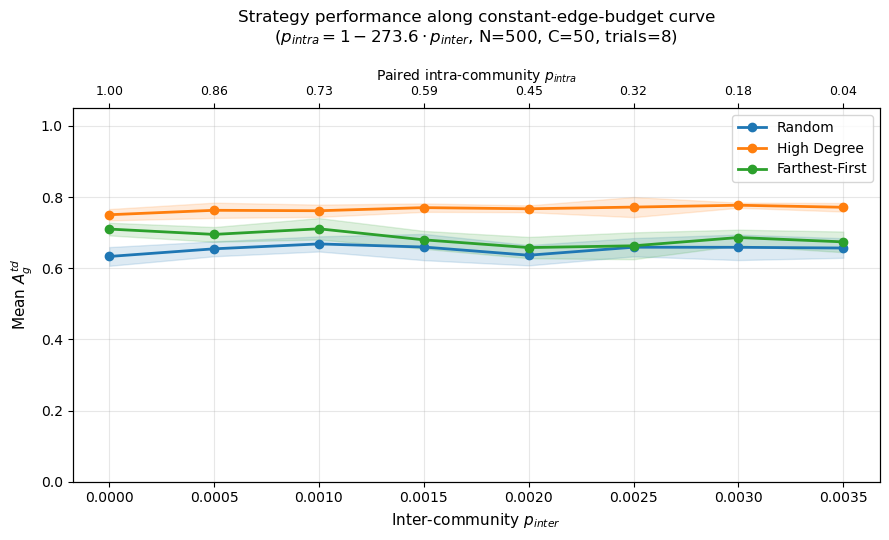

In [7]:
strat_colors = plt.cm.tab10(np.linspace(0, 1, 10))[:len(strat_names)]

fig, ax = plt.subplots(figsize=(9, 5.5))
for si, strat_name in enumerate(strat_names):
    ax.plot(
        P_INTER_VALUES, means[si], color=strat_colors[si], lw=2,
        marker="o", label=strat_name,
    )
    ax.fill_between(
        P_INTER_VALUES,
        means[si] - stds[si], means[si] + stds[si],
        color=strat_colors[si], alpha=0.15,
    )

ax.set_xlabel(r"Inter-community $p_{inter}$", fontsize=11)
ax.set_ylabel(r"Mean $A_g^{td}$", fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend(loc="best")

# Top axis: annotate the paired p_intra at each tick
ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(P_INTER_VALUES)
ax_top.set_xticklabels([f"{v:.2f}" for v in P_INTRA_VALUES], fontsize=9)
ax_top.set_xlabel(r"Paired intra-community $p_{intra}$", fontsize=10)

ax.set_title(
    f"Strategy performance along constant-edge-budget curve\n"
    rf"($p_{{intra}} = 1 - {SLOPE:.1f} \cdot p_{{inter}}$, "
    f"N={N}, C={C}, trials={NUM_TRIALS})",
    fontsize=12, pad=18,
)
fig.tight_layout()
fig.savefig(
    "../figures/cic3_community_sweep_corrected_lines.png",
    dpi=200, bbox_inches="tight",
)
plt.show()

## Plot: Difference vs Random baseline

Each non-random strategy's mean `A_g^td` minus the Random baseline along the
sweep. Positive = strategy beats Random; negative = Random beats strategy.

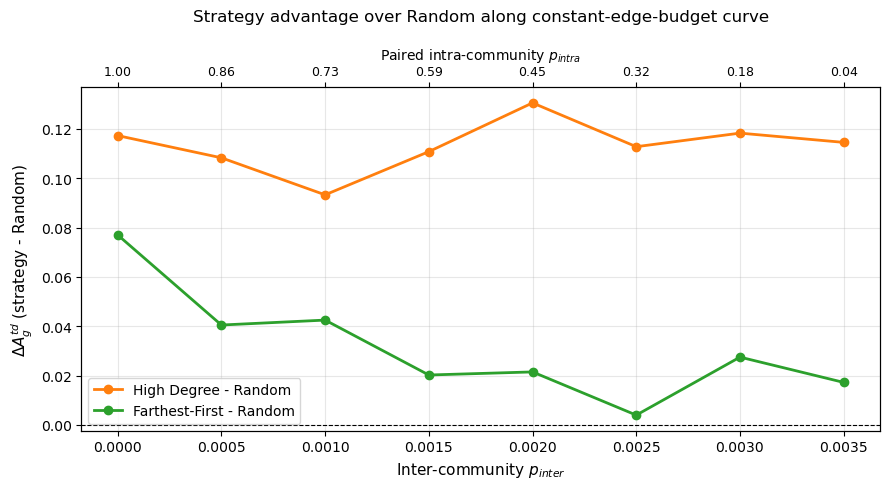

In [8]:
random_idx = strat_names.index("Random")
random_means = means[random_idx]

fig, ax = plt.subplots(figsize=(9, 5))
for si, strat_name in enumerate(strat_names):
    if strat_name == "Random":
        continue
    diff = means[si] - random_means
    ax.plot(
        P_INTER_VALUES, diff, color=strat_colors[si], lw=2,
        marker="o", label=f"{strat_name} - Random",
    )

ax.axhline(0.0, color="black", lw=0.8, ls="--")
ax.set_xlabel(r"Inter-community $p_{inter}$", fontsize=11)
ax.set_ylabel(r"$\Delta A_g^{td}$ (strategy - Random)", fontsize=11)
ax.grid(alpha=0.3)
ax.legend(loc="best")

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())
ax_top.set_xticks(P_INTER_VALUES)
ax_top.set_xticklabels([f"{v:.2f}" for v in P_INTRA_VALUES], fontsize=9)
ax_top.set_xlabel(r"Paired intra-community $p_{intra}$", fontsize=10)

ax.set_title(
    "Strategy advantage over Random along constant-edge-budget curve",
    fontsize=12, pad=18,
)
fig.tight_layout()
fig.savefig(
    "../figures/cic3_community_sweep_corrected_diff.png",
    dpi=200, bbox_inches="tight",
)
plt.show()

## Sanity check: realized degrees along the sweep

Plot realized `k_avg` and `k_delta_avg` to verify the constant-budget
correction is doing its job. Small drift (typically < 1) is expected from
triangle/edge sampling overlap that the analytical correction does not
fully absorb.

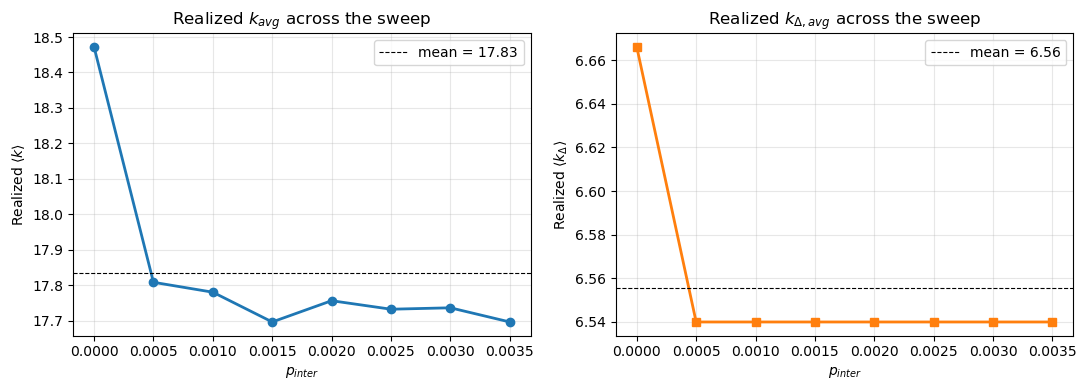

Realized k_avg per sweep point:
  p_inter=0.00000  p_intra=1.0000  k_avg=18.47  k_delta=6.67
  p_inter=0.00050  p_intra=0.8632  k_avg=17.81  k_delta=6.54
  p_inter=0.00100  p_intra=0.7264  k_avg=17.78  k_delta=6.54
  p_inter=0.00150  p_intra=0.5896  k_avg=17.70  k_delta=6.54
  p_inter=0.00200  p_intra=0.4528  k_avg=17.76  k_delta=6.54
  p_inter=0.00250  p_intra=0.3160  k_avg=17.73  k_delta=6.54
  p_inter=0.00300  p_intra=0.1792  k_avg=17.74  k_delta=6.54
  p_inter=0.00350  p_intra=0.0425  k_avg=17.70  k_delta=6.54

k_avg range: [17.70, 18.47]  (spread = 0.78)


In [9]:
k_avg_arr = np.array([realized_k[pi][0] for pi in P_INTER_VALUES])
k_d_arr = np.array([realized_k[pi][1] for pi in P_INTER_VALUES])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(P_INTER_VALUES, k_avg_arr, marker="o", color="tab:blue", lw=2)
ax1.set_xlabel(r"$p_{inter}$")
ax1.set_ylabel(r"Realized $\langle k \rangle$")
ax1.set_title(r"Realized $k_{avg}$ across the sweep")
ax1.grid(alpha=0.3)
ax1.axhline(k_avg_arr.mean(), color="black", lw=0.8, ls="--",
            label=f"mean = {k_avg_arr.mean():.2f}")
ax1.legend(loc="best")

ax2.plot(P_INTER_VALUES, k_d_arr, marker="s", color="tab:orange", lw=2)
ax2.set_xlabel(r"$p_{inter}$")
ax2.set_ylabel(r"Realized $\langle k_\Delta \rangle$")
ax2.set_title(r"Realized $k_{\Delta,avg}$ across the sweep")
ax2.grid(alpha=0.3)
ax2.axhline(k_d_arr.mean(), color="black", lw=0.8, ls="--",
            label=f"mean = {k_d_arr.mean():.2f}")
ax2.legend(loc="best")

fig.tight_layout()
fig.savefig(
    "../figures/cic3_community_sweep_corrected_kavg_check.png",
    dpi=200, bbox_inches="tight",
)
plt.show()

print("Realized k_avg per sweep point:")
for pi, pa, k, kd in zip(P_INTER_VALUES, P_INTRA_VALUES, k_avg_arr, k_d_arr):
    print(
        f"  p_inter={pi:.5f}  p_intra={pa:.4f}  "
        f"k_avg={k:.2f}  k_delta={kd:.2f}"
    )
print(
    f"\nk_avg range: [{k_avg_arr.min():.2f}, {k_avg_arr.max():.2f}]  "
    f"(spread = {k_avg_arr.max() - k_avg_arr.min():.2f})"
)

## Summary table

Best strategy at each sweep point.

In [10]:
print(
    f"{'p_inter':<11s}{'p_intra':<10s}{'k_avg':<10s}"
    f"{'Best Strategy':<20s}{'A_g_td':<10s}"
)
print("-" * 61)
for ji, p_inter in enumerate(P_INTER_VALUES):
    p_intra = P_INTRA_VALUES[ji]
    k = realized_k[p_inter][0]
    best_si = int(np.argmax(means[:, ji]))
    best_strat = strat_names[best_si]
    best_val = means[best_si, ji]
    print(
        f"{p_inter:<11.5f}{p_intra:<10.4f}{k:<10.2f}"
        f"{best_strat:<20s}{best_val:<10.4f}"
    )

p_inter    p_intra   k_avg     Best Strategy       A_g_td    
-------------------------------------------------------------
0.00000    1.0000    18.47     High Degree         0.7502    
0.00050    0.8632    17.81     High Degree         0.7627    
0.00100    0.7264    17.78     High Degree         0.7615    
0.00150    0.5896    17.70     High Degree         0.7702    
0.00200    0.4528    17.76     High Degree         0.7670    
0.00250    0.3160    17.73     High Degree         0.7717    
0.00300    0.1792    17.74     High Degree         0.7770    
0.00350    0.0425    17.70     High Degree         0.7712    
